# bertviz Test run

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from bertviz import head_view, model_view

# Load model
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-3B-Instruct", output_attentions=True, device_map="auto")

# Prepare input
text = "The quick brown fox jumps over the lazy dog"
inputs = tokenizer(text, return_tensors="pt").to(model.device)
outputs = model(**inputs)
attns = outputs.attentions  # tuple of (layers × batch × heads × seq × seq)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
head_view(attns, tokens)
model_view(attns, tokens)


/Users/chenkaihu/miniconda3/envs/llm-learning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.63s/it]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Actual Case

In [12]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model
model_name = "Qwen/Qwen2.5-3B-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_name, output_attentions=True, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_name)


/Users/chenkaihu/miniconda3/envs/llm-learning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.09s/it]
Some parameters are on the meta device because they were offloaded to the disk.


In [4]:
import pandas as pd
output = pd.read_json("output.Addition_9.cot0shot.math_teacher.Qwen2.5-3B-Base.thinking.json")
output.head()

,number1,number2,answer,reason,id,cot0shot.math teacher_input,cot0shot.math teacher_output,cot0shot.math teacher_answer,cot0shot.math teacher_result,cot0shot.math teacher_thinking_CoT,cot0shot.math teacher_output_CoT
0,673436698,538327286,1211763984,Let's add the two numbers digit by digit.\n1. ...,Addition_Q377,Please solve the addition problem in the given...,"The ones place is 9 + 8 = 17, so the ones plac...",1,False,,"The ones place is 9 + 8 = 17, so the ones plac..."
1,351943250,170139784,522083034,Let's add the two numbers digit by digit.\n1. ...,Addition_Q180,Please solve the addition problem in the given...,"The ones place is 5 + 8 = 13, so the ones plac...",521083034,False,,"The ones place is 5 + 8 = 13, so the ones plac..."
2,631529940,831901572,1463431512,Let's add the two numbers digit by digit.\n1. ...,Addition_Q355,Please solve the addition problem in the given...,"The ones place is 9 + 7 = 16, so the ones plac...",1165031512,False,,"The ones place is 9 + 7 = 16, so the ones plac..."
3,750287621,360102348,1110389969,Let's add the two numbers digit by digit.\n1. ...,Addition_Q386,Please solve the addition problem in the given...,The ones place is 2 + 4 = 6.\nThe tens place i...,1110389969,True,,The ones place is 2 + 4 = 6.\nThe tens place i...
4,824190622,203514191,1027704813,Let's add the two numbers digit by digit.\n1. ...,Addition_Q174,Please solve the addition problem in the given...,Let's add the two numbers digit by digit.\n1. ...,1027704813,True,,Let's add the two numbers digit by digit.\n1. ...


In [10]:
instruct = output["cot0shot.math teacher_input"][0]
cot = output["cot0shot.math teacher_output_CoT"][0]

In [13]:
# sample = [['Please solve the math problem.\nQuestion: What is the Product of 73 and 24? Please reason step by step.. I think the correct answer is: 1758\n', "<think>.\nTo find the product of 73 and 24, we can use the distributive property of multiplication over addition. This means we can break down the multiplication into smaller parts that are easier to calculate.\n\nFirst, let's express 24 as a sum of two numbers that are easier to multiply with 73. We can write 24 as 20 + 4. Now, we can use the distributive property to rewrite the multiplication as follows:.\n\n73 * 24 = 73 * (20 + 4).\n\nNext, we distribute the multiplication over the addition:.\n\n73 * (20 + 4) = (73 * 20) + (73 * 4).\n\nNow, we can calculate each term separately:.\n\n73 * 20 = 1460.\n73 * 4 = 292.\n\nFinally, we add the two results together: 1460 + 292. Therefore, my final answer is: "]]
# instruct = sample[0][0]
# cot = sample[0][1]
# cot = cot.replace("Therefore, my final answer is:", "").strip()
messages = [
    {"role": "user", "content": instruct},
    {"role": "assistant", "content": cot}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=False # token(s) that indicate the start of an assistant message will be appended to the formatted output
)

In [14]:
instruct_tokens = tokenizer(instruct, return_tensors="pt")["input_ids"].shape[1]
cot_tokens = tokenizer(cot, return_tensors="pt")["input_ids"].shape[1]

In [15]:
print(text[:-11])

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Please solve the addition problem in the given template.
####
# Question:
What is the sum of <<number1>> and <<number2>>?
# Reasoning:
Let's add the two numbers digit by digit.
1. The ones place: <<digit1>>
2. The tens place: <<digit2>>
<<other digits>>
Answer:
Therefore, the final computed sum is <<answer>>.
####
# Question:
What is the sum of 673436698 and 538327286?
# Reasoning:<|im_end|>
<|im_start|>assistant
The ones place is 9 + 8 = 17, so the ones place of the answer is 7 and the carry is 1.
The tens place is 6 + 2 + 1 = 9, so the tens place of the answer is 9.
The hundreds place is 3 + 7 + 1 = 11, so the hundreds place of the answer is 1 and the carry is 1.
The thousands place is 4 + 8 + 1 = 13, so the thousands place of the answer is 3 and the carry is 1.
The millions place is 6 + 5 + 1 = 12, so the millions place of the answer is 2 and the carry is 1.
The ten mil

In [ ]:
# inputs = tokenizer(text[:-11], return_tensors="pt").to(model.device) # Input ids
# # Original methods to get output attentions
# outputs = model(**inputs, output_attentions=True)
# attns = outputs.attentions  # tuple of (layers × batch × heads × seq × seq)

In [17]:
inputs = tokenizer(text[:-11], return_tensors="pt").to(model.device) # Input ids
gen_out = model.generate(
    **inputs,
    max_new_tokens=128,            # generate up to 128 new tokens
    output_attentions=True,       # tell the forward pass to keep attentions
    return_dict_in_generate=True  # return a GenerationOutput instead of just the tokens
)

seq      = gen_out.sequences                 # (batch, src + new) token ids
attns    = gen_out.attentions                # attns[generated_token][layer][batch_size, num_heads, generated_length, sequence_length]
# https://huggingface.co/docs/transformers/en/internal/generation_utils#transformers.generation.GenerateDecoderOnlyOutput.attentions

RuntimeError: Invalid buffer size: 13.55 GB

In [17]:
# Check the generated sequence
print(tokenizer.batch_decode(seq, skip_special_tokens=False))

["<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nPlease solve the math problem.\nQuestion: What is the Product of 73 and 24? Please reason step by step.. I think the correct answer is: 1758\n<|im_end|>\n<|im_start|>assistant\n<think>.\nTo find the product of 73 and 24, we can use the distributive property of multiplication over addition. This means we can break down the multiplication into smaller parts that are easier to calculate.\n\nFirst, let's express 24 as a sum of two numbers that are easier to multiply with 73. We can write 24 as 20 + 4. Now, we can use the distributive property to rewrite the multiplication as follows:.\n\n73 * 24 = 73 * (20 + 4).\n\nNext, we distribute the multiplication over the addition:.\n\n73 * (20 + 4) = (73 * 20) + (73 * 4).\n\nNow, we can calculate each term separately:.\n\n73 * 20 = 1460.\n73 * 4 = 292.\n\nFinally, we add the two results together: 1460 + 292. Therefore, my final an

In [ ]:
inspect_token_index = 4 # 1-based index in the generated sequence
token_index = inputs["input_ids"].shape[1] + inspect_token_index - 1 # index in the full sequence (input + generated)

assert inspect_token_index < seq.shape[1]-inputs["input_ids"].shape[1], "Inspect token index out of bounds"
assert token_index < seq.shape[1], "Token index out of bounds"

tokens = tokenizer.convert_ids_to_tokens(seq[0], skip_special_tokens=False)[:token_index+1] # select correct subsequence
# Token cleanup
token_labels = [t.replace("Ġ", "") for t in tokens]  # remove BPE artifacts

# Extract attention from last layer
layer_index = -1
selected_layer = attns[inspect_token_index][layer_index] # (heads, seq, seq)
attn_from_i = selected_layer.squeeze()  # (heads, seq)
avg_attn_from_i = attn_from_i.mean(dim=0).cpu().detach().numpy()

In [121]:
print(token_index)
print(len(token_labels))
print(attns[0][-1].shape)
print(attns[1][-1].shape)
print(attns[2][-1].shape)
print(attn_from_i.shape)

270
271
torch.Size([1, 16, 271, 271])
torch.Size([1, 16, 1, 272])
torch.Size([1, 16, 1, 273])
torch.Size([16, 271])


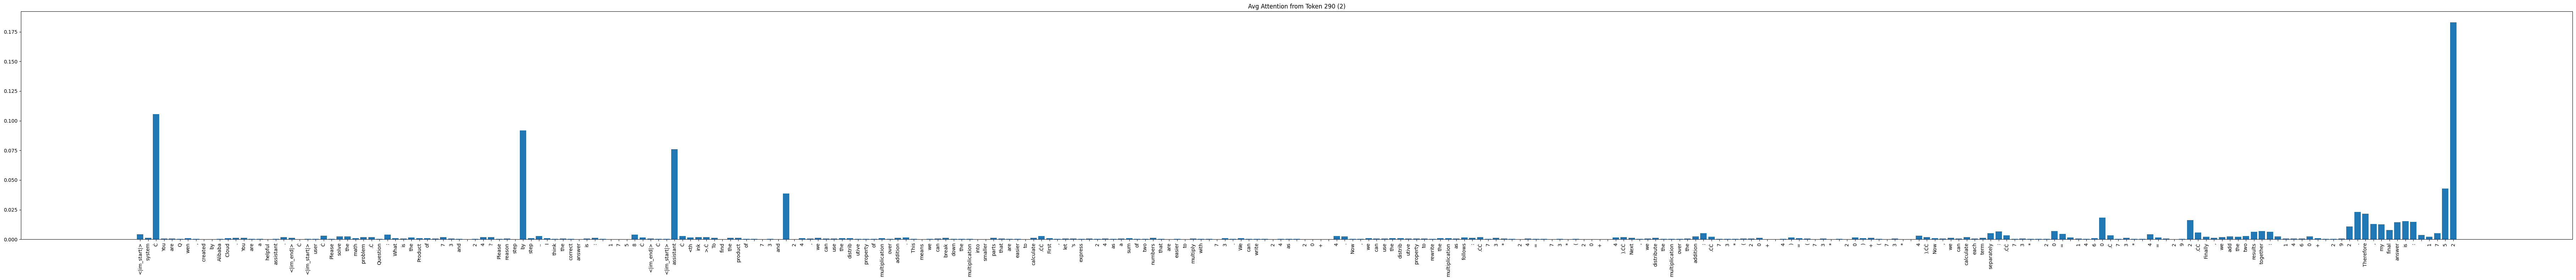

In [19]:
import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(max(12, len(token_labels) * 0.25), 8))
plt.bar(range(len(token_labels)), avg_attn_from_i)
plt.xticks(range(len(token_labels)), token_labels, rotation=90)
plt.title(f"Avg Attention from Token {token_index} ({token_labels[token_index]})")
plt.tight_layout()
plt.show()

Sum of attention scores:
Instruction: 0.2348
Chain of thought: 0.3051


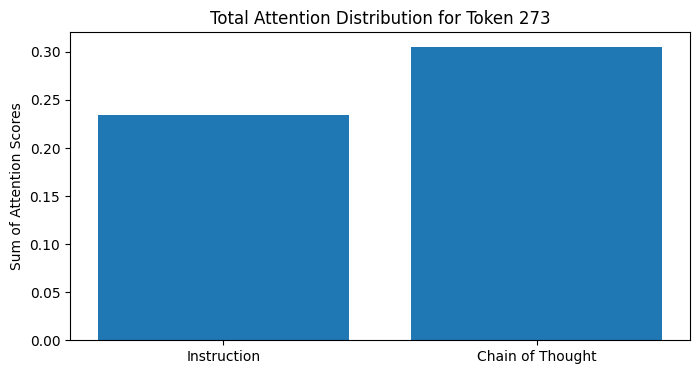

In [12]:
instruct_attention = avg_attn_from_i[:instruct_tokens].sum()
cot_attention = avg_attn_from_i[instruct_tokens:instruct_tokens+cot_tokens].sum()

# Print results
print(f"Sum of attention scores:")
print(f"Instruction: {instruct_attention:.4f}")
print(f"Chain of thought: {cot_attention:.4f}")

# Create a bar plot comparing the two
plt.figure(figsize=(8, 4))
plt.bar(['Instruction', 'Chain of Thought'], [instruct_attention, cot_attention])
plt.title(f"Total Attention Distribution for Token {token_index}")
plt.ylabel("Sum of Attention Scores")
plt.show()